# RiskGuard 🛡️
## Notebook 03: Feature Engineering & Target Definition (Member 2)

This notebook details:
1. Feature extraction from PAIMANA infrastructure monitoring
2. Schedule variance and delay day calculations
3. Binary target formulation (`target_delayed`)
4. Sector inference from implementing agencies
5. Target leakage verification


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

paimana_file = os.path.join("..", "data", "processed", "paimana", "paimana_clean.csv")
df = pd.read_csv(paimana_file)
print(f"Loaded {len(df)} cleaned project records.")


Loaded 1941 cleaned project records.


### 1. Target Variable Formulation & Distribution

Delay Target Distribution:
target_delayed
1    1196
0     745
Name: count, dtype: int64

Proportions:
target_delayed
1    0.616177
0    0.383823
Name: proportion, dtype: float64


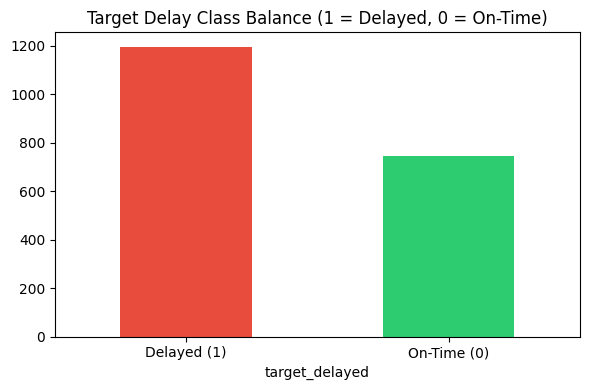

In [2]:
print("Delay Target Distribution:")
print(df["target_delayed"].value_counts(dropna=False))
print("\nProportions:")
print(df["target_delayed"].value_counts(normalize=True))

fig, ax = plt.subplots(figsize=(6, 4))
df["target_delayed"].value_counts().plot(kind="bar", color=["#e74c3c", "#2ecc71"], ax=ax)
ax.set_title("Target Delay Class Balance (1 = Delayed, 0 = On-Time)")
ax.set_xticklabels(["Delayed (1)", "On-Time (0)"], rotation=0)
plt.tight_layout()
plt.show()


### 2. Cost Overrun & Financial Ratios

In [3]:
overrun_summary = df[["original_cost", "revised_cost", "cost_overrun", "cost_overrun_percent", "expenditure_ratio"]].describe()
display(overrun_summary)


,original_cost,revised_cost,cost_overrun,cost_overrun_percent,expenditure_ratio
count,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000
mean,1848.975358,2138.155100,289.179742,8.626389,0.415373
std,4980.889445,7291.335446,3686.348589,50.615904,1.406323
min,102.400000,0.100000,-8874.000000,-99.958099,0.000000
25%,352.010000,353.270000,0.000000,0.000000,0.064634
50%,769.930000,770.120000,0.000000,0.000000,0.346480
75%,1501.020000,1635.440000,12.950000,1.423853,0.626311
max,108000.000000,188000.000000,126891.000000,1231.528018,60.600000


### 3. Anti-Leakage Verification Checklist

In [4]:
# Verify schedule_delay_days is kept out of X_train
print("Target definition: target_delayed = 1 if schedule_delay_days > 0 else 0")
print("Confirmation: schedule_delay_days is an outcome proxy and will strictly NOT be used as a predictor feature in X.")


Target definition: target_delayed = 1 if schedule_delay_days > 0 else 0
Confirmation: schedule_delay_days is an outcome proxy and will strictly NOT be used as a predictor feature in X.
